# Mixed Linear Models

### imports, colours, maps

In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

IBM_COLORBLIND = [
    "#ffb000",  # yellow
    "#fe6100",  # orange
    "#dc267f",  # pink
    "#785ef0",  # purple
    "#648fff",  # blue
]
IBM_COLORS = [
    "#6929c4",  # Purple 70
    "#1192e8",  # Cyan 50
    "#005d5d",  # Teal 70
    "#9f1853",  # Magenta 70
    "#fa4d56",  # Red 50
    "#570408",  # Red 90
    "#198038",  # Green 60
    "#002d9c",  # Blue 80
    "#ee538b",  # Magenta 50
    "#b28600",  # Yellow 50
    "#009d9a",  # Teal 50
    "#012749",  # Cyan 90
    "#8a3800",  # Orange 70
    "#a56eff",  # Purple 50
]
IBM_LIGHT = [
    "#8a3ffc",  # Purple 60
    "#33b1ff",  # Cyan 40
    "#007d79",  # Teal 60
    "#ff7eb6",  # Magenta 40
    "#fa4d56",  # Red 50
    "#fff1f1",  # Red 10 (very light)
    "#6fdc8c",  # Green 30
    "#4589ff",  # Blue 50
    "#d12771",  # Magenta 60
    "#d2a106",  # Yellow 40
    "#08bdba",  # Teal 40
    "#bae6ff",  # Cyan 20 (very light)
    "#ba4e00",  # Orange 60
    "#d4bbff",  # Purple 30 (very light)
]

CONDS = {
    "Nelo": "Baseline",
    "Coda": "Proactive",
    "Lumo": "Optional"
}

### data prep

In [165]:
blocks = pd.read_csv("../DATA/blocks.csv")

In [166]:
merged = pd.read_csv("../DATA/merged.csv")
demo = pd.read_csv("../DATA/demo.csv")

merged = merged[merged["block_x"] != "trial"]
df = blocks.merge(demo, on="participant_id")

# condition and id have to be categories for lmm
df["condition"] = df["condition"].astype("category")
df["participant_id"] = df["participant_id"].astype("category")


#add age
df["age"] = 2026 - df["birth_year"]
df["age_z"] = (df["age"] - df["age"].mean()) / df["age"].std()

# add experience as cat
df["vr_experience"] = df["vr_experience"].astype("category")
df["automation_experience"] = df["automation_experience"].astype("category")

df["drivers_license"] = df["drivers_license"].map({"No": 0, "Yes": 1})

df["automation_familiarity_z"] = (df["automation_familiarity"] - df["automation_familiarity"].mean()) / df["automation_familiarity"].std()

mapping = {
    "never": 0,
    "rarely": 1,
    "Several times a week": 2,
    "Daily": 3
}

df["driving_frequency"] = df["driving_frequency"].map(mapping)

df["driving_frequency_z"] = (df["driving_frequency"] - df["driving_frequency"].mean()) / df["driving_frequency"].std()

# variables
traits = [
    "tri_score",
    "nfc_score",
    "bfi_extraversion",
    "bfi_agreeableness",
    "bfi_conscientiousness",
    "bfi_neuroticism",
    "bfi_openness"
]

outcomes = ["trust", "understanding", "nasa"]

df["condition_label"] = df["condition"].map(CONDS)

### Standardise traits

In [167]:
scaler = StandardScaler()

for trait in traits:
    df[f"{trait}_z"] = scaler.fit_transform(df[[trait]])

## Linear mixed models

### separate models for each trait

In [ ]:
results_dict = {}

for outcome in outcomes:
    print(f"\n\n==============================")
    print(f"OUTCOME: {outcome.upper()}")
    print(f"==============================")

    results_dict[outcome] = {}

    for trait in traits:
        trait_z = f"{trait}_z"

        print(f"\n--- Trait: {trait} ---")

        model = smf.mixedlm(
            f"{outcome} ~ condition * {trait_z}",
            data=df,
            groups=df["participant_id"]
        )

        result = model.fit()
        print(result.summary())

        results_dict[outcome][trait] = result


summary_rows = []

for outcome in outcomes:
    for trait in traits:

        res = results_dict[outcome][trait]
        trait_z = f"{trait}_z"

        for param in res.params.index:

            if "condition" in param and trait_z in param:
                summary_rows.append({
                    "outcome": outcome,
                    "trait": trait,
                    "interaction": param,
                    "beta": res.params[param],
                    "p": res.pvalues[param]
                })

summary_df = pd.DataFrame(summary_rows)

print("\n\n=== INTERACTION SUMMARY ===")
print(summary_df.sort_values("p"))

### one big model

- maximal random-effects structure including random slopes for condition
- models converge and variance components indicated meaningful between-subject variability in condition effects

In [ ]:
results_dict = {}
traits.append("age")
#traits.append("driving_frequency")
#traits.append("automation_familiarity")

for outcome in outcomes:
    print(f"\n\n==============================")
    print(f"OUTCOME: {outcome.upper()}")
    print(f"==============================")


    trait_terms = [f"{trait}_z" for trait in traits]

    fixed_effects = " + ".join(trait_terms)
    interactions = " + ".join([f"condition:{t}" for t in trait_terms])

    formula = f"{outcome} ~ condition + {fixed_effects} + {interactions}"

    model = smf.mixedlm(
        formula,
        data=df,
        groups=df["participant_id"],
        re_formula="~condition"
    )

    result = model.fit()
    print(result.summary())

    results_dict[outcome] = result

summary_rows = []

for outcome, res in results_dict.items():
    #print(res.params.index.tolist())
    for param in res.params.index:
        if "condition" in param and ":" in param:  # all interaction terms
            summary_rows.append({
                "outcome": outcome,
                "interaction": param,
                "beta": res.params[param],
                "p": res.pvalues[param]
            })

summary_df = pd.DataFrame(summary_rows)

print("\n\n=== INTERACTION SUMMARY ===")
print(summary_df.sort_values("p"))

### Interaction plot

In [192]:
def plot_interaction(df, trait, outcome):
    order = ["Optional", "Proactive", "Baseline"]
    plt.rcParams['font.family'] = 'serif'
    plt.figure(figsize=(8, 5), dpi=300)

    sns.lmplot(
        data=df,
        x=f"{trait}_z",
        y=outcome,
        hue="condition_label",
        palette=IBM_LIGHT,
        height=6,
        aspect=1.2,
        scatter_kws={"alpha": 0.5},
        line_kws={"linewidth": 2},
        hue_order=order,
        legend=False,
        ci=False,
    )

    plt.grid(True, linestyle=":", linewidth=0.6, alpha=0.6)

    plt.title(f"{outcome.title()} by {trait.replace('_', ' ').title()} × Condition", fontsize=16, family="serif")
    plt.xlabel(f"{trait.replace('_', ' ').title()} (standardised)", fontsize=16, family="serif")
    plt.ylabel(outcome.title(), fontsize=16, family="serif")
    plt.legend(title="Condition", prop = {'family': "serif"})

    plt.show()

In [259]:
def plot_interaction(df, trait, outcome, palette):
    order = ["Optional", "Proactive", "Baseline"]

    sns.set_theme(
        style="whitegrid",
        context="paper",
        font="serif",
        rc={
            "axes.titlesize": 14,
            "axes.labelsize": 12,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "legend.fontsize": 10,
            "legend.title_fontsize": 11,
        },
    )

    fig, ax = plt.subplots(figsize=(6.5, 4.5), dpi=300)


    for cond in order:
        subset = df[df["condition_label"] == cond]
        sns.regplot(
            data=subset,
            x=f"{trait}_z",
            y=outcome,
            scatter=False,
            ax=ax,
            label=cond,
            color=palette[order.index(cond)],
            line_kws={"linewidth": 2},
           # ci=False,
        )

    #ax.set_xlabel(f"{trait.replace('_', ' ').title()} (standardised)")
    #ax.set_xlabel("Technology Readiness Index z-Score")
    ax.set_xlabel("Negative Emotionality z-Score")
    #ax.set_ylabel(outcome.replace("_", " ").title())
    ax.set_ylabel("Mental Workload")
    #ax.set_ylim(bottom=0)

    ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.7)
    sns.despine()

    # Legend
    ax.legend(title="Condition", frameon=False)

    plt.tight_layout()
    plt.show()

In [269]:
def plot_interaction(df, trait, outcome, palette):
    order = ["Optional", "Proactive", "Baseline"]
    linestyles = ["solid", "dashed", "dotted"]

    sns.set_theme(style="whitegrid", context="paper", font="serif")

    fig, ax = plt.subplots(figsize=(6.5, 4.5), dpi=300)
    ax.set_xticks([-2, -1, 0, 1, 2])
    # X values for smooth lines
    x_vals = np.linspace(df[f"{trait}_z"].min(), df[f"{trait}_z"].max(), 100)

    # Plot regression lines + markers
    for i, cond in enumerate(order):
        subset = df[df["condition_label"] == cond]

        # Fit simple linear model
        coeffs = np.polyfit(subset[f"{trait}_z"], subset[outcome], 1)
        y_vals = np.polyval(coeffs, x_vals)

        # Line
        ax.plot(
            x_vals,
            y_vals,
            linestyle=linestyles[i],
            linewidth=2,
            color=palette[i],
            label=cond,
        )

        # --- Dots at tick positions ---
        xticks = ax.get_xticks()
        y_ticks_pred = np.polyval(coeffs, xticks)

        ax.scatter(
            xticks,
            y_ticks_pred,
            color=palette[i],
            s=25,
            zorder=3,
        )

    ax.set_xlabel(f"{trait.replace('_', ' ').title()} (standardised)")
    ax.set_ylabel(outcome.replace("_", " ").title())

    # Styling
    ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.7)
    sns.despine()
    ax.legend(title="Condition", frameon=False)

    plt.tight_layout()
    plt.show()

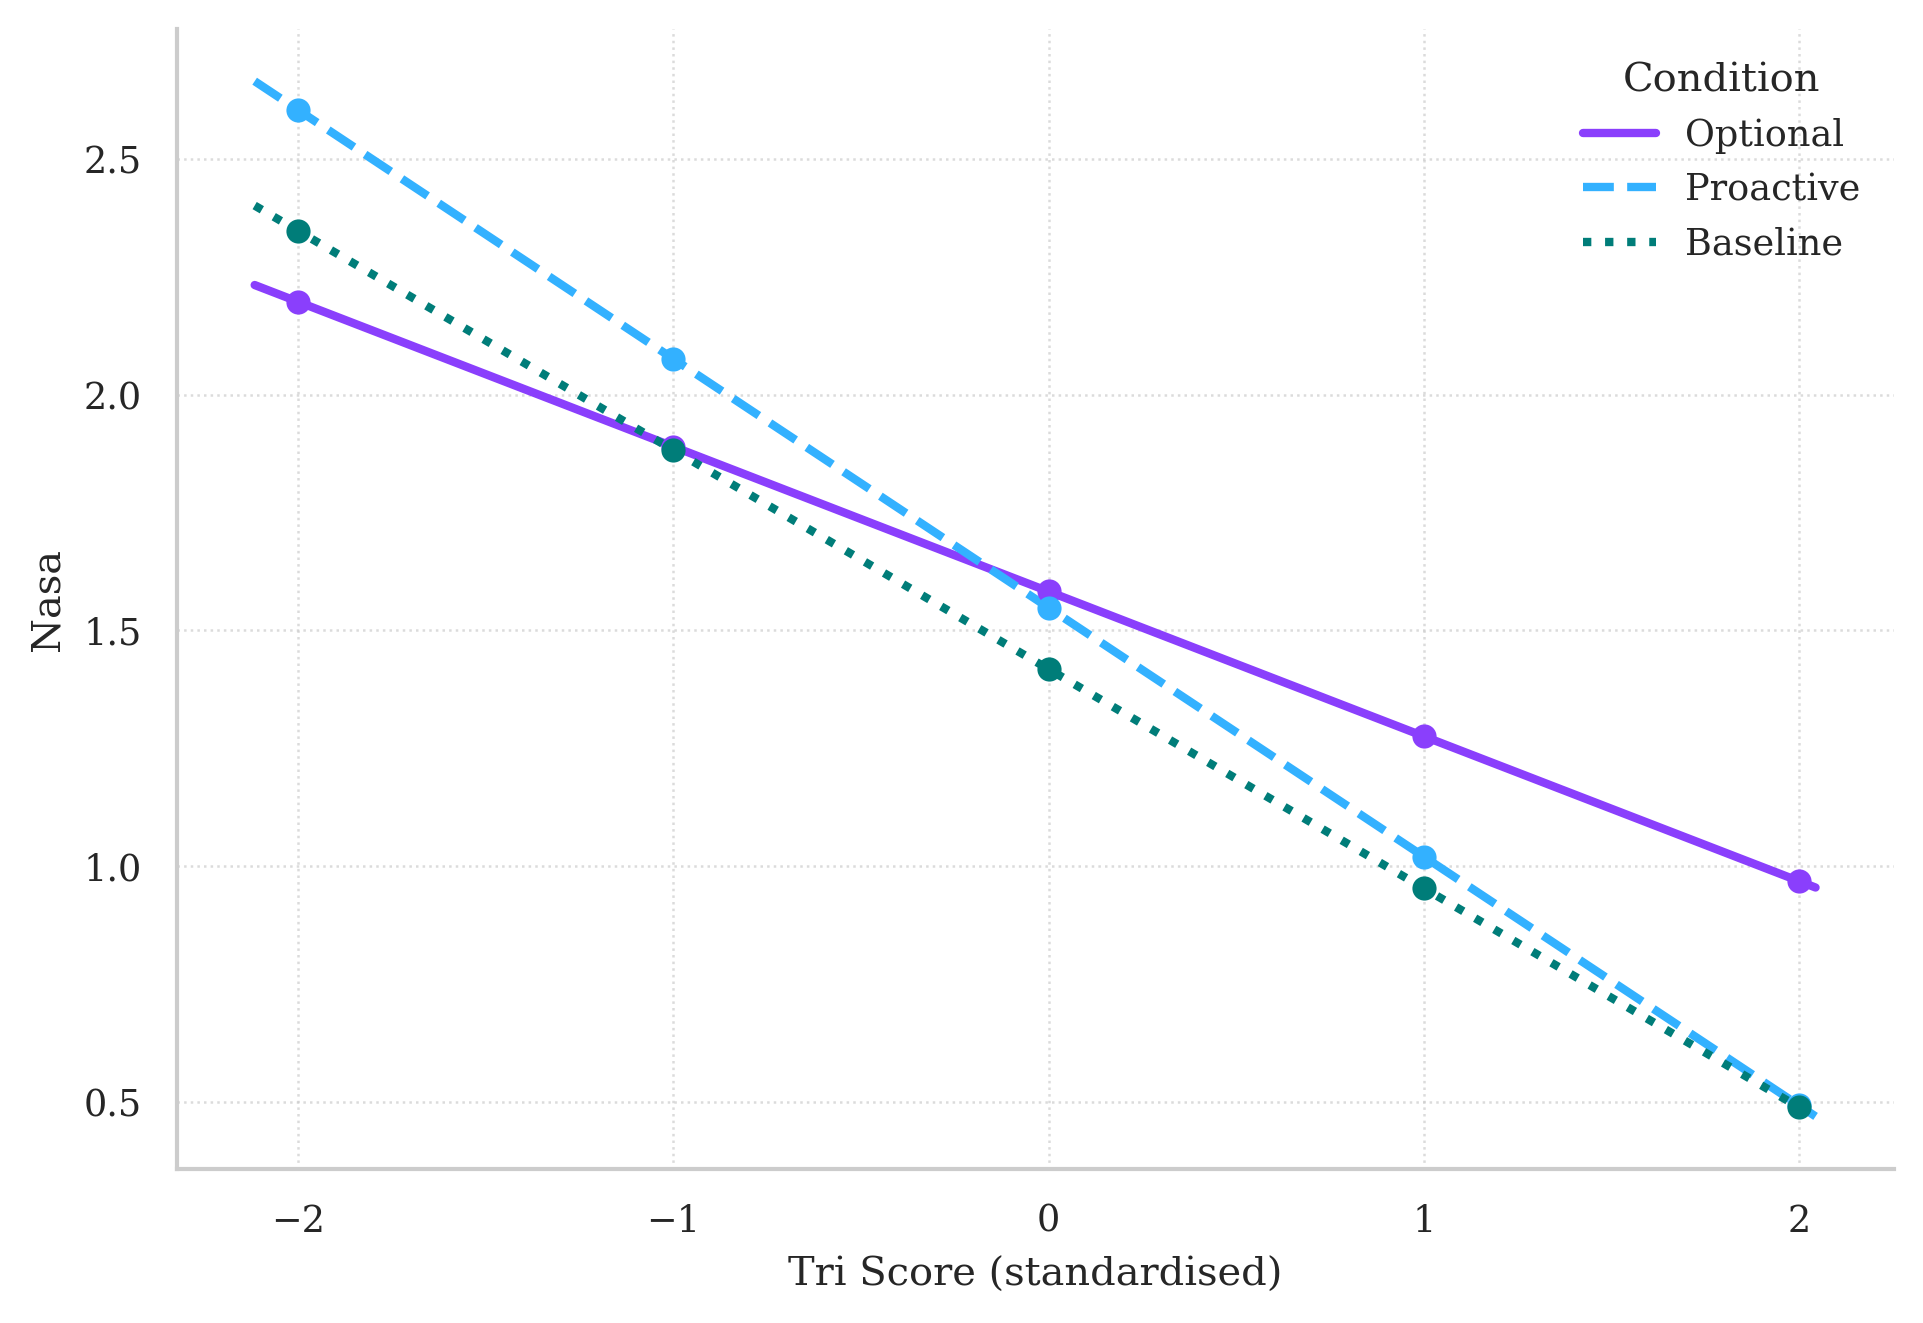

In [271]:
plot_interaction(df, "tri_score", "nasa", IBM_LIGHT)